# 212 — Raw ERSP clustering (band-aware downsampled 15×30)

Same canonical sample set as 210, but each ERSP is compressed from full-res
(129 × 300 = 38,700 features) to a neuroscience-band-aware 15 × 30 = 450 features
before clustering. Dim reduction before clustering typically lifts silhouettes 2–4×
vs raw 38k-dim space (Becht et al. 2019), and band-aware (vs uniform) spacing keeps
each EEG band (delta, theta, alpha, beta, gamma, HG, HFO sub-bands) represented by
at least one bin.

Outputs land in `outputs/clustering/{kmeans,hierarchical}/rawds/runs/<timestamp>/`.
MOBA picks up the new `rawds` feature_set automatically via index.json.


In [19]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

from sklearn.preprocessing import StandardScaler
from functions.lf_features  import (
    downsample_ersp_to_bands,
    build_X_3d_downsampled,
    FREQ_BANDS_15_TO_400HZ,
)
from functions import lf_cluster_run as R
from functions import lf_blob_clustering_config as cfg

SCRIPT_NAME = '212_raw_downsampled_clustering.ipynb'


## Config

In [20]:
# ── data input ─────────────────────────────
INPUT_DIR = Path(r'\\\\nasac-m2.unige.ch\\m-HumanNeuronLab\\ANALYSIS\\FLM\\Analysis_LoraFanda\\01_FBM_Analysis\\outputs\\04_ersp_LM_RAWONLY')
if not INPUT_DIR.exists():
    INPUT_DIR = Path('../01_FBM_Analysis/outputs/04_ersp_LM_RAWONLY').resolve()

# ── downsampling ───────────────────────────
# Each tuple = one output freq band (lo_hz, hi_hz). Default = 15 bands spanning
# 1..400 Hz, finer at low freq, coarser at HFO. Override here to tweak.
FREQ_BAND_EDGES = FREQ_BANDS_15_TO_400HZ
FMAX_HZ         = 500.0     # upper edge of the ORIGINAL ERSP freq axis (Hz).
                            # If your ERSP was computed with fmax=400, set this to 400.
TIME_BINS_OUT   = 30        # target time-axis length (300 -> 30 = 10x downsample)

# ── clustering ─────────────────────────────
KMEANS_K_RANGE = [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
HC_METHOD      = 'ward'
HC_METRIC      = 'euclidean'
RANDOM_STATE   = cfg.RANDOM_STATE

print('FREQ_BAND_EDGES:')
for i, (lo, hi) in enumerate(FREQ_BAND_EDGES):
    print(f'  bin {i:2d}: {lo:>5.0f}–{hi:>5.0f} Hz')
print(f'FMAX_HZ = {FMAX_HZ}  TIME_BINS_OUT = {TIME_BINS_OUT}')
print(f'Output feature dim per sample = {len(FREQ_BAND_EDGES) * TIME_BINS_OUT}')


FREQ_BAND_EDGES:
  bin  0:     1–    4 Hz
  bin  1:     4–    8 Hz
  bin  2:     8–   13 Hz
  bin  3:    13–   20 Hz
  bin  4:    20–   30 Hz
  bin  5:    30–   50 Hz
  bin  6:    50–   70 Hz
  bin  7:    70–  100 Hz
  bin  8:   100–  130 Hz
  bin  9:   130–  170 Hz
  bin 10:   170–  220 Hz
  bin 11:   220–  270 Hz
  bin 12:   270–  320 Hz
  bin 13:   320–  360 Hz
  bin 14:   360–  400 Hz
FMAX_HZ = 500.0  TIME_BINS_OUT = 30
Output feature dim per sample = 450


## Load canonical dataset (shared across 210/230/231/232/212)

In [21]:
# Loads ERSPs from INPUT_DIR, drops non-neural channels, applies the
# high-activity gate. Same canonical sample set as 210/230/231/232 so
# cross-comparison is valid.
from functions.lf_dataset import prepare_dataset, DEFAULT_CACHE_DIR

df_meta, ersp_list, X_3d_full = prepare_dataset(INPUT_DIR, cache_dir=DEFAULT_CACHE_DIR)
print(f'\nCanonical dataset: {len(df_meta)} samples · X_3d_full.shape={X_3d_full.shape}')
df_meta.head()


[lf_dataset cache hit] \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\_dataset\canonical
  2095 samples · X_3d.shape=(2095, 129, 300)

Canonical dataset: 2095 samples · X_3d_full.shape=(2095, 129, 300)


,patient_id,condition,task,electrode,file_path,prop_above_pos,prop_below_neg,high_activity,sample_idx
0,EL030,audio,LM,A_L10,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,0.096951,0.015995,True,0
1,EL030,audio,LM,A_L11,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,0.117080,0.018734,True,1
2,EL030,audio,LM,A_L12,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,0.133127,0.030982,True,2
3,EL030,audio,LM,A_L13,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,0.163643,0.060853,True,3
4,EL030,audio,LM,A_L14,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,0.155504,0.064031,True,4


## Downsample: 129 × 300 → 15 × 30

Per-band mean across the freq axis (drops everything above `FMAX_HZ` and
compresses to one bin per neuroscience band), then anti-aliased resize
of the time axis from 300 → `TIME_BINS_OUT`. Same skimage `resize` used
by `lf_minus101.downsample_minus101_map`.


In [22]:
X_3d_ds = build_X_3d_downsampled(
    ersp_list,
    freq_band_edges=FREQ_BAND_EDGES,
    fmax_hz=FMAX_HZ,
    time_bins_out=TIME_BINS_OUT,
)
print('X_3d_ds.shape:', X_3d_ds.shape)

X_raw = X_3d_ds.reshape(X_3d_ds.shape[0], -1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
print('X_scaled.shape:', X_scaled.shape, '  (n_samples × 450)')
print('Mean ~0, std ~1?  mean[:5]:', X_scaled[:, :5].mean(axis=0).round(3))
print('                  std[:5]: ', X_scaled[:, :5].std(axis=0).round(3))


[build_X_3d_downsampled] 2095 samples · 15 freq bins · 30 time bins · flat dim = 450
X_3d_ds.shape: (2095, 15, 30)
X_scaled.shape: (2095, 450)   (n_samples × 450)
Mean ~0, std ~1?  mean[:5]: [-0.  0. -0. -0. -0.]
                  std[:5]:  [1. 1. 1. 1. 1.]


## QC: sanity-check a grid of downsampled ERSPs

Pick 20 random samples and plot their downsampled ERSP. The gross spectro-
temporal pattern should be visible — HG should be a clear stripe, beta
should be visible at low freq, baseline should be ~0.


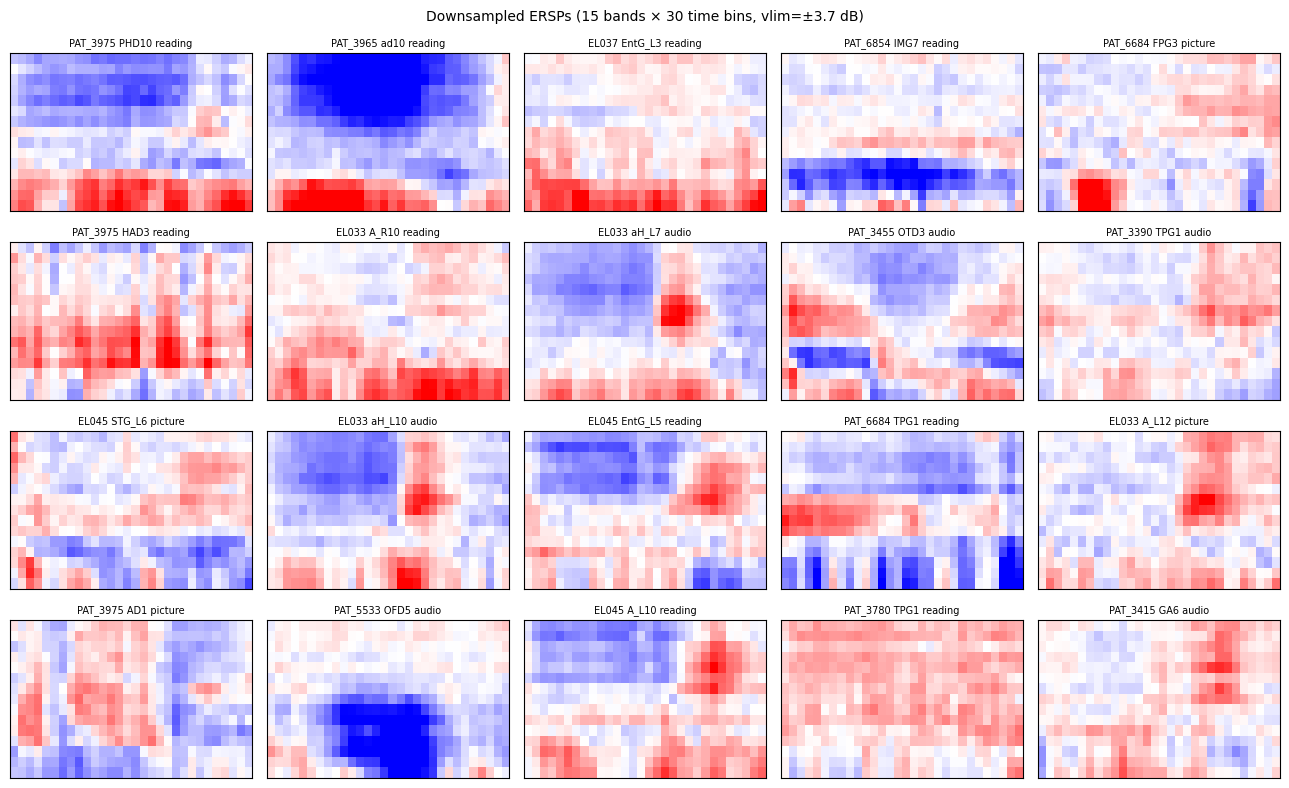

In [23]:
rng = np.random.default_rng(42)
qc_idx = rng.choice(len(X_3d_ds), size=min(20, len(X_3d_ds)), replace=False)

n_cols = 5
n_rows = int(np.ceil(len(qc_idx) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.6 * n_cols, 2.0 * n_rows))
axes = np.atleast_1d(axes).ravel()
vlim = float(np.percentile(np.abs(X_3d_ds[qc_idx]), 98))
for ax, i in zip(axes, qc_idx):
    ax.imshow(X_3d_ds[i], aspect='auto', origin='lower', cmap='bwr',
              vmin=-vlim, vmax=vlim, interpolation='nearest')
    m = df_meta.iloc[int(i)]
    ax.set_title(f"{m['patient_id']} {m['electrode']} {m['condition']}", fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])
for ax in axes[len(qc_idx):]:
    ax.axis('off')
fig.suptitle(f'Downsampled ERSPs ({len(FREQ_BAND_EDGES)} bands × {TIME_BINS_OUT} time bins, vlim=±{vlim:.1f} dB)',
             fontsize=10)
plt.tight_layout()
plt.show()


# Resolution sweep: silhouette vs freq_bins × time_bins


In [24]:
# # ── Resolution sweep: silhouette + Jaccard vs freq_bins × time_bins × K ─────
# from sklearn.preprocessing import StandardScaler as _SS
# from sklearn.metrics import silhouette_score as _sil_score
# from sklearn.cluster import KMeans as _KM
# from skimage.transform import resize as _resize

# FREQ_SWEEP     = [120, 90, 60, 30, 15, 8, 4]      # frequency band counts to test
# TIME_SWEEP     = [60, 30, 15, 8, 3]      # time bin counts to test
# K_SWEEP        = list(range(5, 20))  # K=5..15
# N_JACCARD_RUNS = 50                  # KMeans refits per (resolution, K) for Jaccard
#                                      # keep low (20) since this is a sweep not final validation
# JACCARD_SUBSAMPLE = None              # subsample rows for Jaccard speed (set None to use all)

# BAND_SETS = {
#     30: None,   # uniform resize
#     15: FREQ_BAND_EDGES,
#     8:  [(1,8),(8,13),(13,30),(30,70),(70,130),(130,220),(220,320),(320,400)],
#     4:  [(1,13),(13,70),(70,220),(220,400)],
# }

# def _downsample_sweep(ersp_list, freq_bins, time_bins, fmax=FMAX_HZ):
#     result = []
#     for ersp in ersp_list:
#         band_edges = BAND_SETS.get(freq_bins)
#         if band_edges is not None:
#             n_freq_orig = ersp.shape[0]
#             freq_axis = np.linspace(0, fmax, n_freq_orig)
#             rows = []
#             for lo, hi in band_edges:
#                 mask = (freq_axis >= lo) & (freq_axis < hi)
#                 rows.append(ersp[mask].mean(axis=0) if mask.any() else np.zeros(ersp.shape[1]))
#             ds = np.stack(rows, axis=0)
#         else:
#             ds = _resize(ersp, (freq_bins, ersp.shape[1]), anti_aliasing=True)
#         ds = _resize(ds, (freq_bins, time_bins), anti_aliasing=True)
#         result.append(ds.ravel())
#     X = np.stack(result, axis=0)
#     return _SS().fit_transform(X)

# def _jaccard_stability(X, k, n_runs=N_JACCARD_RUNS, subsample=JACCARD_SUBSAMPLE):
#     """
#     Lightweight Jaccard: run KMeans n_runs times, build consensus matrix,
#     return mean intra-cluster co-occurrence (= mean Jaccard across clusters).
#     If subsample is set, uses a random subset of rows for speed.
#     """
#     n = X.shape[0]
#     if subsample and n > subsample:
#         rng = np.random.default_rng(42)
#         idx = rng.choice(n, size=subsample, replace=False)
#         X_s = X[idx]
#     else:
#         X_s = X
#         idx = np.arange(n)

#     ns = X_s.shape[0]
#     consensus = np.zeros((ns, ns), dtype=np.float32)
#     for r in range(n_runs):
#         lbl = _KM(n_clusters=k, random_state=r, n_init=5).fit_predict(X_s)
#         for c in np.unique(lbl):
#             ci = np.where(lbl == c)[0]
#             if ci.size > 1:
#                 consensus[np.ix_(ci, ci)] += 1.0
#     consensus /= float(n_runs)

#     # Mean intra-cluster Jaccard across all clusters (using best-K labels)
#     best_lbl = _KM(n_clusters=k, random_state=99, n_init=10).fit_predict(X_s)
#     jacc_per_cluster = []
#     for c in np.unique(best_lbl):
#         ci = np.where(best_lbl == c)[0]
#         if ci.size < 2: continue
#         block = consensus[np.ix_(ci, ci)]
#         mask = ~np.eye(block.shape[0], dtype=bool)
#         jacc_per_cluster.append(float(block[mask].mean()))
#     return float(np.mean(jacc_per_cluster)) if jacc_per_cluster else float('nan')

# # ── Main sweep ────────────────────────────────────────────────────────────────
# # Results stored as dicts keyed by (freq_bins, time_bins, K)
# # For each resolution: best_sil, best_K, mean_sil, best_jaccard at best_K
# print('Running resolution × K sweep...')
# print(f'  {len(FREQ_SWEEP)} freq × {len(TIME_SWEEP)} time × {len(K_SWEEP)} K values '
#       f'= {len(FREQ_SWEEP)*len(TIME_SWEEP)*len(K_SWEEP)} fits + '
#       f'{len(FREQ_SWEEP)*len(TIME_SWEEP)} Jaccard computations')

# # Store per-resolution summary (best K chosen by silhouette)
# sil_grid    = np.full((len(FREQ_SWEEP), len(TIME_SWEEP)), np.nan)   # best sil across K
# jacc_grid   = np.full((len(FREQ_SWEEP), len(TIME_SWEEP)), np.nan)   # Jaccard at best K
# bestk_grid  = np.full((len(FREQ_SWEEP), len(TIME_SWEEP)), np.nan)   # best K

# # Full K-by-resolution sil curves (for the per-resolution line plots below)
# sil_curves  = {}   # key=(fi,ti) -> array of shape (len(K_SWEEP),)

# for fi, fb in enumerate(FREQ_SWEEP):
#     for ti, tb in enumerate(TIME_SWEEP):
#         print(f'\n  freq={fb} bands × time={tb} bins', flush=True)
#         try:
#             X_sw = _downsample_sweep(ersp_list, fb, tb)
#         except Exception as e:
#             print(f'    downsample failed: {e}'); continue

#         sils = []
#         for k in K_SWEEP:
#             try:
#                 lbl = _KM(n_clusters=k, random_state=42, n_init=10).fit_predict(X_sw)
#                 s = _sil_score(X_sw, lbl, sample_size=min(500, len(X_sw)))
#                 sils.append(s)
#                 print(f'    K={k:2d}  sil={s:.4f}')
#             except Exception as e:
#                 sils.append(float('nan'))
#                 print(f'    K={k:2d}  ERROR: {e}')

#         sil_curves[(fi, ti)] = np.array(sils)
#         best_ki = int(np.nanargmax(sils))
#         best_k  = K_SWEEP[best_ki]
#         best_s  = sils[best_ki]
#         sil_grid[fi, ti]   = best_s
#         bestk_grid[fi, ti] = best_k

#         # Jaccard at best K only (expensive — only compute once per resolution)
#         try:
#             j = _jaccard_stability(X_sw, best_k)
#             jacc_grid[fi, ti] = j
#             print(f'    → best K={best_k}  sil={best_s:.4f}  jaccard={j:.4f}')
#         except Exception as e:
#             print(f'    → Jaccard failed: {e}')

# print('\nSweep complete.')

# # ── Figure 1: Silhouette heatmap (best K per resolution) ─────────────────────
# fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# for ax, grid, title, fmt in [
#     (axes[0], sil_grid,  'Best silhouette (optimal K per resolution)', '.3f'),
#     (axes[1], jacc_grid, 'Jaccard stability at best K',                '.3f'),
# ]:
#     vmin, vmax = np.nanmin(grid) - 0.01, np.nanmax(grid) + 0.01
#     im = ax.imshow(grid, aspect='auto', cmap='RdYlGn', vmin=vmin, vmax=vmax)
#     ax.set_xticks(range(len(TIME_SWEEP))); ax.set_xticklabels([str(t) for t in TIME_SWEEP])
#     ax.set_yticks(range(len(FREQ_SWEEP))); ax.set_yticklabels([str(f) for f in FREQ_SWEEP])
#     ax.set_xlabel('Time bins'); ax.set_ylabel('Freq bands')
#     ax.set_title(title)
#     for fi in range(len(FREQ_SWEEP)):
#         for ti_i in range(len(TIME_SWEEP)):
#             v = grid[fi, ti_i]
#             if not np.isnan(v):
#                 ax.text(ti_i, fi, format(v, fmt), ha='center', va='center',
#                         fontsize=8, color='black' if v > np.nanmean(grid) else 'white')
#     plt.colorbar(im, ax=ax)

# fig.suptitle('Resolution sweep — silhouette vs Jaccard tradeoff', fontsize=11)
# fig.tight_layout()
# plt.show()

# # ── Figure 2: Best K heatmap ──────────────────────────────────────────────────
# fig2, ax2 = plt.subplots(figsize=(6, 4))
# im2 = ax2.imshow(bestk_grid, aspect='auto', cmap='viridis',
#                  vmin=K_SWEEP[0], vmax=K_SWEEP[-1])
# ax2.set_xticks(range(len(TIME_SWEEP))); ax2.set_xticklabels([str(t) for t in TIME_SWEEP])
# ax2.set_yticks(range(len(FREQ_SWEEP))); ax2.set_yticklabels([str(f) for f in FREQ_SWEEP])
# ax2.set_xlabel('Time bins'); ax2.set_ylabel('Freq bands')
# ax2.set_title('Best K (by silhouette) per resolution')
# for fi in range(len(FREQ_SWEEP)):
#     for ti_i in range(len(TIME_SWEEP)):
#         v = bestk_grid[fi, ti_i]
#         if not np.isnan(v):
#             ax2.text(ti_i, fi, str(int(v)), ha='center', va='center', fontsize=9, color='white')
# plt.colorbar(im2, ax=ax2, label='K')
# fig2.tight_layout()
# plt.show()

# # ── Figure 3: Silhouette-vs-K curves per resolution ──────────────────────────
# fig3, axes3 = plt.subplots(len(FREQ_SWEEP), len(TIME_SWEEP),
#                             figsize=(3 * len(TIME_SWEEP), 2.5 * len(FREQ_SWEEP)),
#                             sharex=True, sharey=True)
# for fi, fb in enumerate(FREQ_SWEEP):
#     for ti_i, tb in enumerate(TIME_SWEEP):
#         ax = axes3[fi][ti_i]
#         curve = sil_curves.get((fi, ti_i))
#         if curve is not None:
#             ax.plot(K_SWEEP, curve, marker='o', ms=4, lw=1.5, color='#b85c6e')
#             best_ki = int(np.nanargmax(curve))
#             ax.axvline(K_SWEEP[best_ki], color='#7a8c6e', lw=1, ls='--', alpha=0.8)
#         ax.set_title(f'f={fb} t={tb}', fontsize=8)
#         ax.set_xlabel('K', fontsize=7)
#         ax.set_ylabel('sil', fontsize=7)
#         ax.tick_params(labelsize=7)
# fig3.suptitle('Silhouette vs K for each resolution', fontsize=11)
# fig3.tight_layout()
# plt.show()

# # ── Summary ───────────────────────────────────────────────────────────────────
# best_fi, best_ti = np.unravel_index(np.nanargmax(sil_grid), sil_grid.shape)
# print(f'\nBest by silhouette:  freq={FREQ_SWEEP[best_fi]} bands  '
#       f'time={TIME_SWEEP[best_ti]} bins  '
#       f'K={int(bestk_grid[best_fi, best_ti])}  '
#       f'sil={sil_grid[best_fi, best_ti]:.4f}  '
#       f'jaccard={jacc_grid[best_fi, best_ti]:.4f}')

# # Combined score: equal weight silhouette + Jaccard (both normalized to their range)
# sil_norm  = (sil_grid  - np.nanmin(sil_grid))  / (np.nanmax(sil_grid)  - np.nanmin(sil_grid)  + 1e-9)
# jacc_norm = (jacc_grid - np.nanmin(jacc_grid)) / (np.nanmax(jacc_grid) - np.nanmin(jacc_grid) + 1e-9)
# combined  = (sil_norm + jacc_norm) / 2
# best_fi2, best_ti2 = np.unravel_index(np.nanargmax(combined), combined.shape)
# print(f'Best by sil+jaccard: freq={FREQ_SWEEP[best_fi2]} bands  '
#       f'time={TIME_SWEEP[best_ti2]} bins  '
#       f'K={int(bestk_grid[best_fi2, best_ti2])}  '
#       f'sil={sil_grid[best_fi2, best_ti2]:.4f}  '
#       f'jaccard={jacc_grid[best_fi2, best_ti2]:.4f}')

# Improved Monti et al: 

In [25]:
# ── Build X_hg from ersp_list (mirrors 232_hg_clustering.ipynb) ──────────────
from functions.lf_hg import build_hg_feature_matrix
X_hg = build_hg_feature_matrix(ersp_list, hg_band=(70.0, 150.0), fmax=FMAX_HZ)

[build_hg_feature_matrix] X_hg.shape=(2095, 300)  hg_band=(70.0, 150.0) Hz  fmax=500.0 Hz


In [ ]:
# ── Monti-inspired downsampling evaluation with HG gold standard ──────────────
from sklearn.preprocessing import StandardScaler as _SS
from sklearn.metrics import silhouette_score as _sil_score, adjusted_rand_score as _ari
from sklearn.cluster import KMeans as _KM
from skimage.transform import resize as _resize
from scipy.stats import spearmanr as _spearmanr
import warnings

# ── Config ────────────────────────────────────────────────────────────────────
FREQ_SWEEP     = [30, 15, 8, 4]
TIME_SWEEP     = [30, 15, 8, 3]
K_SWEEP        = list(range(5, 16))
N_RUNS         = 30
SUBSAMPLE_FRAC = 0.80
RANDOM_STATE   = 42

BAND_SETS = {
    30: None,
    15: FREQ_BAND_EDGES,
    8:  [(1,8),(8,13),(13,30),(30,70),(70,130),(130,220),(220,320),(320,400)],
    4:  [(1,13),(13,70),(70,220),(220,400)],
}

# ── Core functions ────────────────────────────────────────────────────────────
def _downsample(ersp_list, freq_bins, time_bins, fmax=FMAX_HZ):
    result = []
    for ersp in ersp_list:
        band_edges = BAND_SETS.get(freq_bins)
        if band_edges is not None:
            freq_axis = np.linspace(0, fmax, ersp.shape[0])
            rows = []
            for lo, hi in band_edges:
                mask = (freq_axis >= lo) & (freq_axis < hi)
                rows.append(ersp[mask].mean(axis=0) if mask.any()
                            else np.zeros(ersp.shape[1]))
            ds = np.stack(rows, axis=0)
        else:
            ds = _resize(ersp, (freq_bins, ersp.shape[1]), anti_aliasing=True)
        ds = _resize(ds, (freq_bins, time_bins), anti_aliasing=True)
        result.append(ds.ravel())
    return _SS().fit_transform(np.stack(result, axis=0))

def _downsample_3d(ersp_list, freq_bins, time_bins, fmax=FMAX_HZ):
    """Same as _downsample but returns (n, freq_bins, time_bins) unscaled."""
    result = []
    for ersp in ersp_list:
        band_edges = BAND_SETS.get(freq_bins)
        if band_edges is not None:
            freq_axis = np.linspace(0, fmax, ersp.shape[0])
            rows = []
            for lo, hi in band_edges:
                mask = (freq_axis >= lo) & (freq_axis < hi)
                rows.append(ersp[mask].mean(axis=0) if mask.any()
                            else np.zeros(ersp.shape[1]))
            ds = np.stack(rows, axis=0)
        else:
            ds = _resize(ersp, (freq_bins, ersp.shape[1]), anti_aliasing=True)
        ds = _resize(ds, (freq_bins, time_bins), anti_aliasing=True)
        result.append(ds)
    return np.stack(result, axis=0)  # (n, freq_bins, time_bins)

def _monti_consensus(X, k, n_runs=N_RUNS, subsample_frac=SUBSAMPLE_FRAC,
                     rs=RANDOM_STATE):
    """
    True Monti consensus: subsample 80% without replacement at each run.
    Returns (n x n) consensus matrix M and indicator matrix I_sum.
    M[i,j] = fraction of runs where i,j were BOTH present AND in same cluster.
    """
    n = X.shape[0]
    n_sub = int(np.floor(n * subsample_frac))
    M_sum = np.zeros((n, n), dtype=np.float32)
    I_sum = np.zeros((n, n), dtype=np.float32)
    rng = np.random.default_rng(rs)
    for r in range(n_runs):
        idx = rng.choice(n, size=n_sub, replace=False)
        idx_sorted = np.sort(idx)
        X_sub = X[idx_sorted]
        lbl = _KM(n_clusters=k, random_state=int(rs + r),
                  n_init=5).fit_predict(X_sub)
        I_sum[np.ix_(idx_sorted, idx_sorted)] += 1.0
        for c in np.unique(lbl):
            ci = idx_sorted[lbl == c]
            if ci.size > 1:
                M_sum[np.ix_(ci, ci)] += 1.0
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        M = np.where(I_sum > 0, M_sum / I_sum, 0.0).astype(np.float32)
    return M, I_sum

def _cdf_area(M):
    """Monti's area under the CDF of off-diagonal consensus matrix entries."""
    n = M.shape[0]
    triu_idx = np.triu_indices(n, k=1)
    vals = np.sort(M[triu_idx])
    m = len(vals)
    cdf = np.arange(1, m + 1) / m
    return float(np.trapz(cdf, vals))

def _best_k_by_cdf(X, k_range, n_runs=N_RUNS, subsample_frac=SUBSAMPLE_FRAC,
                   rs=RANDOM_STATE):
    """
    Monti K-selection: compute consensus matrix for each K, find best K where
    Delta(K) = (A(K+1)-A(K))/A(K) levels off.
    Returns best_k, areas dict, deltas dict.
    """
    areas = {}
    for k in k_range:
        M, _ = _monti_consensus(X, k, n_runs=n_runs,
                                subsample_frac=subsample_frac, rs=rs)
        areas[k] = _cdf_area(M)
    deltas = {}
    ks_sorted = sorted(areas.keys())
    for i, k in enumerate(ks_sorted):
        if i == 0:
            deltas[k] = areas[k]
        else:
            prev_k = ks_sorted[i - 1]
            deltas[k] = (areas[k] - areas[prev_k]) / max(areas[prev_k], 1e-9)
    best_k = max(deltas, key=lambda k: deltas[k])
    return best_k, areas, deltas

# ── Step 1: References ────────────────────────────────────────────────────────

# --- HG reference (PRIMARY gold standard) ---
print('Step 1a: Computing HG reference (primary gold standard)...')
X_hg_scaled = _SS().fit_transform(X_hg.astype(np.float32))
best_k_hg, areas_hg, deltas_hg = _best_k_by_cdf(
    X_hg_scaled, K_SWEEP, n_runs=N_RUNS)
print(f'  HG best K (Monti CDF): {best_k_hg}')
M_hg, _ = _monti_consensus(X_hg_scaled, best_k_hg, n_runs=N_RUNS)
labels_hg = _KM(
    n_clusters=best_k_hg, random_state=RANDOM_STATE, n_init=20
).fit_predict(X_hg_scaled)
n = M_hg.shape[0]
triu_idx = np.triu_indices(n, k=1)
M_hg_flat = M_hg[triu_idx]
X_hg_raw = X_hg.astype(np.float32)   # unscaled, for reconstruction fidelity
print(f'  HG CDF area at best K = {areas_hg[best_k_hg]:.4f}')

# --- Full-res proxy reference (SECONDARY) ---
# Use 15 bands × 60 time bins as full-res proxy:
#   - faster than raw 129×300 (38,700 features)
#   - band-aware so comparable to sweep resolutions
#   - still captures full spectral content
print('\nStep 1b: Computing full-res proxy reference (15 bands × 60 time bins)...')
X_fullres_proxy = _downsample(ersp_list, freq_bins=15, time_bins=60)
best_k_full, areas_full, deltas_full = _best_k_by_cdf(
    X_fullres_proxy, K_SWEEP, n_runs=N_RUNS)
print(f'  Full-res proxy best K (Monti CDF): {best_k_full}')
M_full, _ = _monti_consensus(X_fullres_proxy, best_k_full, n_runs=N_RUNS)
labels_full = _KM(
    n_clusters=best_k_full, random_state=RANDOM_STATE, n_init=20
).fit_predict(X_fullres_proxy)
M_full_flat = M_full[triu_idx]
print(f'  Full-res proxy CDF area at best K = {areas_full[best_k_full]:.4f}')

# ── Step 2: Sweep ─────────────────────────────────────────────────────────────
print('\nStep 2: Sweeping resolutions...')
print(f'  {len(FREQ_SWEEP)} freq × {len(TIME_SWEEP)} time × {len(K_SWEEP)} K values')

# Storage grids
frob_grid      = np.full((len(FREQ_SWEEP), len(TIME_SWEEP)), np.nan)
spear_grid     = np.full((len(FREQ_SWEEP), len(TIME_SWEEP)), np.nan)
ari_grid       = np.full((len(FREQ_SWEEP), len(TIME_SWEEP)), np.nan)
cdf_grid       = np.full((len(FREQ_SWEEP), len(TIME_SWEEP)), np.nan)
bestk_grid     = np.full((len(FREQ_SWEEP), len(TIME_SWEEP)), np.nan)
sil_grid       = np.full((len(FREQ_SWEEP), len(TIME_SWEEP)), np.nan)
spear_hg_grid  = np.full((len(FREQ_SWEEP), len(TIME_SWEEP)), np.nan)
ari_hg_grid    = np.full((len(FREQ_SWEEP), len(TIME_SWEEP)), np.nan)
hg_recon_grid  = np.full((len(FREQ_SWEEP), len(TIME_SWEEP)), np.nan)

for fi, fb in enumerate(FREQ_SWEEP):
    for ti, tb in enumerate(TIME_SWEEP):
        print(f'\n  freq={fb} bands × time={tb} bins', flush=True)

        # Downsample
        try:
            X_sw = _downsample(ersp_list, fb, tb)
        except Exception as e:
            print(f'    downsample failed: {e}'); continue

        # K selection (Monti CDF)
        try:
            best_k_sw, areas_sw, _ = _best_k_by_cdf(X_sw, K_SWEEP, n_runs=N_RUNS)
            bestk_grid[fi, ti] = best_k_sw
            cdf_grid[fi, ti]   = areas_sw[best_k_sw]
            print(f'    best K (Monti CDF) = {best_k_sw}, '
                  f'CDF area = {areas_sw[best_k_sw]:.4f}')
        except Exception as e:
            print(f'    K selection failed: {e}'); continue

        # Consensus matrix at this resolution's best K
        try:
            M_sw, _ = _monti_consensus(X_sw, best_k_sw, n_runs=N_RUNS)
            M_sw_flat = M_sw[triu_idx]
        except Exception as e:
            print(f'    Consensus matrix failed: {e}'); continue

        # ── Full-res structural comparisons ───────────────────────────────────
        try:
            frob = float(np.linalg.norm(M_full - M_sw, 'fro'))
            frob_grid[fi, ti] = frob
            rho, _ = _spearmanr(M_full_flat, M_sw_flat)
            spear_grid[fi, ti] = float(rho)
            print(f'    Frobenius vs full-res M = {frob:.4f}, '
                  f'Spearman ρ = {rho:.4f}')
        except Exception as e:
            print(f'    Full-res comparison failed: {e}')

        try:
            labels_sw = _KM(
                n_clusters=best_k_full,
                random_state=RANDOM_STATE, n_init=10
            ).fit_predict(X_sw)
            ari = float(_ari(labels_full, labels_sw))
            ari_grid[fi, ti] = ari
            print(f'    ARI vs full-res labels (K={best_k_full}) = {ari:.4f}')
        except Exception as e:
            print(f'    Full-res ARI failed: {e}')

        # ── HG gold standard comparisons ★ ───────────────────────────────────
        try:
            rho_hg, _ = _spearmanr(M_hg_flat, M_sw_flat)
            spear_hg_grid[fi, ti] = float(rho_hg)
            print(f'    Spearman ρ vs HG M = {rho_hg:.4f}  ★')
        except Exception as e:
            print(f'    HG Spearman failed: {e}')

        try:
            labels_sw_hgk = _KM(
                n_clusters=best_k_hg,
                random_state=RANDOM_STATE, n_init=10
            ).fit_predict(X_sw)
            ari_hg = float(_ari(labels_hg, labels_sw_hgk))
            ari_hg_grid[fi, ti] = ari_hg
            print(f'    ARI vs HG labels (K={best_k_hg}) = {ari_hg:.4f}  ★')
        except Exception as e:
            print(f'    HG ARI failed: {e}')

        # HG reconstruction fidelity
        try:
            band_edges = BAND_SETS.get(fb)
            if band_edges is not None:
                hg_rows = [i for i, (lo, hi) in enumerate(band_edges)
                           if hi > 70 and lo < 150]
            else:
                edges = np.linspace(0, FMAX_HZ, fb + 1)
                hg_rows = [i for i in range(fb)
                           if edges[i + 1] > 70 and edges[i] < 150]

            if hg_rows:
                X_3d_sw = _downsample_3d(ersp_list, fb, tb)  # (n, fb, tb)
                hg_comp = X_3d_sw[:, hg_rows, :].mean(axis=1)  # (n, tb)

                # Resize compressed HG time axis back to original length
                hg_comp_resized = np.stack([
                    _resize(row.reshape(1, -1),
                            (1, X_hg_raw.shape[1]),
                            anti_aliasing=True).ravel()
                    for row in hg_comp
                ], axis=0)

                corrs = [
                    float(np.corrcoef(X_hg_raw[i], hg_comp_resized[i])[0, 1])
                    for i in range(len(X_hg_raw))
                ]
                hg_recon_grid[fi, ti] = float(np.nanmean(corrs))
                print(f'    HG reconstruction fidelity (mean r) = '
                      f'{hg_recon_grid[fi, ti]:.4f}  ★')
            else:
                print(f'    HG reconstruction: no HG rows found for fb={fb}')
        except Exception as e:
            print(f'    HG reconstruction failed: {e}')

        # Silhouette (secondary)
        try:
            labels_sw_bk = _KM(
                n_clusters=best_k_sw,
                random_state=RANDOM_STATE, n_init=10
            ).fit_predict(X_sw)
            sil = float(_sil_score(X_sw, labels_sw_bk,
                                   sample_size=min(500, len(X_sw))))
            sil_grid[fi, ti] = sil
        except Exception as e:
            pass

print('\nSweep complete.')

# ── Step 3: Figures ───────────────────────────────────────────────────────────
# 3×3 layout:
#   Row 1 — HG gold standard (primary)
#   Row 2 — Full-res structural preservation (secondary)
#   Row 3 — Monti CDF + silhouette + best K (tertiary)

all_metrics = [
    # Row 1 — HG gold standard
    (spear_hg_grid, 'Spearman ρ vs HG consensus M\n★ PRIMARY', '.3f', 'RdYlGn'),
    (ari_hg_grid,   f'ARI vs HG labels (K={best_k_hg})\n★ PRIMARY', '.3f', 'RdYlGn'),
    (hg_recon_grid, 'HG band reconstruction fidelity\nmean Pearson r  ★', '.3f', 'RdYlGn'),
    # Row 2 — Full-res structural preservation
    (spear_grid,    'Spearman ρ vs full-res consensus M', '.3f', 'RdYlGn'),
    (ari_grid,      f'ARI vs full-res labels (K={best_k_full})', '.3f', 'RdYlGn'),
    (frob_grid,     'Frobenius dist to full-res M\n(lower = better)', '.1f', 'RdYlGn_r'),
    # Row 3 — Tertiary
    (cdf_grid,      'CDF area at best K\n(Monti: higher = cleaner)', '.3f', 'RdYlGn'),
    (sil_grid,      'Silhouette at best K\n(reference only)', '.3f', 'RdYlGn'),
    (bestk_grid,    'Best K selected\n(Monti CDF criterion)', 'd', 'viridis'),
]

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.ravel()
for ax, (grid, title, fmt, cmap) in zip(axes, all_metrics):
    vmin = np.nanmin(grid) - 0.01 * abs(np.nanmin(grid))
    vmax = np.nanmax(grid) + 0.01 * abs(np.nanmax(grid))
    im = ax.imshow(grid, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(TIME_SWEEP)))
    ax.set_xticklabels([str(t) for t in TIME_SWEEP])
    ax.set_yticks(range(len(FREQ_SWEEP)))
    ax.set_yticklabels([str(f) for f in FREQ_SWEEP])
    ax.set_xlabel('Time bins')
    ax.set_ylabel('Freq bands')
    ax.set_title(title, fontsize=9)
    for fi_i in range(len(FREQ_SWEEP)):
        for ti_i in range(len(TIME_SWEEP)):
            v = grid[fi_i, ti_i]
            if not np.isnan(v):
                txt = str(int(v)) if fmt == 'd' else format(v, fmt)
                ax.text(ti_i, fi_i, txt, ha='center', va='center', fontsize=8,
                        color='black'
                        if 0.3 < (v - vmin) / max(vmax - vmin, 1e-9) < 0.7
                        else 'white')
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle(
    f'Downsampling evaluation — HG gold standard + Monti structural preservation\n'
    f'HG ref K={best_k_hg} · full-res proxy ref K={best_k_full}',
    fontsize=11)
fig.tight_layout()
plt.show()

# ── Step 4: K-selection CDF curves for both references ───────────────────────
fig2, axes2 = plt.subplots(2, 2, figsize=(12, 7))

for row, (areas, deltas, best_k, label) in enumerate([
    (areas_hg,   deltas_hg,   best_k_hg,   'HG (primary)'),
    (areas_full, deltas_full, best_k_full, 'Full-res proxy'),
]):
    axes2[row][0].bar(list(areas.keys()), list(areas.values()),
                      color='#b85c6e', alpha=0.8)
    axes2[row][0].set_xlabel('K')
    axes2[row][0].set_ylabel('CDF area A(K)')
    axes2[row][0].set_title(f'{label}: CDF area by K')

    axes2[row][1].bar(list(deltas.keys()), list(deltas.values()),
                      color='#7a8c6e', alpha=0.8)
    axes2[row][1].axhline(0, color='black', lw=0.8, ls='--')
    axes2[row][1].axvline(best_k, color='#b85c6e', lw=1.5, ls='--',
                          label=f'best K={best_k}')
    axes2[row][1].set_xlabel('K')
    axes2[row][1].set_ylabel('Δ(K)')
    axes2[row][1].set_title(f'{label}: ΔA(K)')
    axes2[row][1].legend(fontsize=9)

fig2.suptitle('Monti K-selection curves for both references', fontsize=11)
fig2.tight_layout()
plt.show()

# ── Step 5: Composite recommendation ─────────────────────────────────────────
def _norm(g):
    lo, hi = np.nanmin(g), np.nanmax(g)
    return (g - lo) / max(hi - lo, 1e-9)

spear_n    = _norm(spear_grid)
ari_n      = _norm(ari_grid)
frob_n     = 1 - _norm(frob_grid)        # lower Frobenius = better
spear_hg_n = _norm(spear_hg_grid)
ari_hg_n   = _norm(ari_hg_grid)
hg_recon_n = _norm(hg_recon_grid)

# HG metrics weighted 2× — neuroscientific ground truth
composite = (
    1 * spear_n    +
    1 * ari_n      +
    1 * frob_n     +
    2 * spear_hg_n +
    2 * ari_hg_n   +
    2 * hg_recon_n
) / 9

best_fi, best_ti = np.unravel_index(np.nanargmax(composite), composite.shape)

print(f'\n{"="*60}')
print(f'RECOMMENDATION (HG-weighted composite):')
print(f'  freq = {FREQ_SWEEP[best_fi]} bands')
print(f'  time = {TIME_SWEEP[best_ti]} bins')
print(f'  best K (Monti CDF)          = {int(bestk_grid[best_fi, best_ti])}')
print(f'  --- HG gold standard ★ ---')
print(f'  Spearman ρ vs HG M          = {spear_hg_grid[best_fi, best_ti]:.4f}')
print(f'  ARI vs HG labels            = {ari_hg_grid[best_fi, best_ti]:.4f}')
print(f'  HG reconstruction fidelity  = {hg_recon_grid[best_fi, best_ti]:.4f}')
print(f'  --- Full-res structural ---')
print(f'  Spearman ρ vs full-res M    = {spear_grid[best_fi, best_ti]:.4f}')
print(f'  ARI vs full-res labels      = {ari_grid[best_fi, best_ti]:.4f}')
print(f'  Frobenius dist              = {frob_grid[best_fi, best_ti]:.4f}')
print(f'  --- Secondary ---')
print(f'  Silhouette                  = {sil_grid[best_fi, best_ti]:.4f}')
print(f'{"="*60}')

# Also show top 3 resolutions by composite score for comparison
flat_composite = composite.ravel()
top3_idx = np.argsort(flat_composite)[::-1][:3]
print('\nTop 3 resolutions by composite score:')
for rank, idx in enumerate(top3_idx):
    fi_i, ti_i = np.unravel_index(idx, composite.shape)
    print(f'  #{rank+1}: freq={FREQ_SWEEP[fi_i]} bands × time={TIME_SWEEP[ti_i]} bins  '
          f'composite={flat_composite[idx]:.4f}  '
          f'HG-ARI={ari_hg_grid[fi_i, ti_i]:.3f}  '
          f'HG-recon={hg_recon_grid[fi_i, ti_i]:.3f}  '
          f'sil={sil_grid[fi_i, ti_i]:.3f}')


Step 1a: Computing HG reference (primary gold standard)...
  HG best K (Monti CDF): 5
  HG CDF area at best K = 0.7416

Step 1b: Computing full-res proxy reference (15 bands × 60 time bins)...
  Full-res proxy best K (Monti CDF): 5
  Full-res proxy CDF area at best K = 0.7735

Step 2: Sweeping resolutions...
  4 freq × 4 time × 11 K values

  freq=30 bands × time=30 bins
    best K (Monti CDF) = 5, CDF area = 0.6966
    Frobenius vs full-res M = 915.2056, Spearman ρ = 0.4880
    ARI vs full-res labels (K=5) = 0.2951
    Spearman ρ vs HG M = 0.4291  ★
    ARI vs HG labels (K=5) = 0.2731  ★
    HG reconstruction fidelity (mean r) = 0.8617  ★

  freq=30 bands × time=15 bins
    best K (Monti CDF) = 5, CDF area = 0.7092
    Frobenius vs full-res M = 911.5211, Spearman ρ = 0.4882
    ARI vs full-res labels (K=5) = 0.2940
    Spearman ρ vs HG M = 0.4269  ★
    ARI vs HG labels (K=5) = 0.2629  ★
    HG reconstruction fidelity (mean r) = 0.7994  ★

  freq=30 bands × time=8 bins
    best K (Mon

In [ ]:
# # ── Monti-inspired downsampling evaluation ────────────────────────────────────
# # For each resolution, compute the consensus matrix using PROPER Monti resampling
# # (subsample 80% without replacement, N_RUNS times). Then compare each compressed
# # resolution's consensus matrix to the full-resolution consensus matrix using:
# #
# #   1. Frobenius distance: ||M_full - M_compressed||_F  (lower = more similar)
# #   2. Spearman correlation of off-diagonal entries     (higher = more similar)
# #   3. CDF area (Monti's own criterion) at best K       (tells you if the
# #      compressed space still has clean cluster structure)
# #   4. ARI between full-res best-K labels and compressed best-K labels
# #      (directly: do the same samples cluster together?)
# #
# # This answers the real question: "does compression preserve the same structure?"
# # rather than "does compression give high silhouette in its own space?"

# from sklearn.preprocessing import StandardScaler as _SS
# from sklearn.metrics import silhouette_score as _sil_score, adjusted_rand_score as _ari
# from sklearn.cluster import KMeans as _KM
# from skimage.transform import resize as _resize
# from scipy.stats import spearmanr as _spearmanr
# import warnings

# # ── Config ────────────────────────────────────────────────────────────────────
# FREQ_SWEEP     = [30, 15, 8, 4]
# TIME_SWEEP     = [30, 15, 8, 3]
# K_SWEEP        = list(range(5, 16))
# N_RUNS         = 30          # Monti resampling runs (paper uses 500; 30 is fine for sweep)
# SUBSAMPLE_FRAC = 0.80        # Monti uses 80%
# RANDOM_STATE   = 42

# BAND_SETS = {
#     30: None,
#     15: FREQ_BAND_EDGES,
#     8:  [(1,8),(8,13),(13,30),(30,70),(70,130),(130,220),(220,320),(320,400)],
#     4:  [(1,13),(13,70),(70,220),(220,400)],
# }

# def _downsample(ersp_list, freq_bins, time_bins, fmax=FMAX_HZ):
#     result = []
#     for ersp in ersp_list:
#         band_edges = BAND_SETS.get(freq_bins)
#         if band_edges is not None:
#             n_freq_orig = ersp.shape[0]
#             freq_axis = np.linspace(0, fmax, n_freq_orig)
#             rows = []
#             for lo, hi in band_edges:
#                 mask = (freq_axis >= lo) & (freq_axis < hi)
#                 rows.append(ersp[mask].mean(axis=0) if mask.any() else np.zeros(ersp.shape[1]))
#             ds = np.stack(rows, axis=0)
#         else:
#             ds = _resize(ersp, (freq_bins, ersp.shape[1]), anti_aliasing=True)
#         ds = _resize(ds, (freq_bins, time_bins), anti_aliasing=True)
#         result.append(ds.ravel())
#     return _SS().fit_transform(np.stack(result, axis=0))

# def _monti_consensus(X, k, n_runs=N_RUNS, subsample_frac=SUBSAMPLE_FRAC, rs=RANDOM_STATE):
#     """
#     TRUE Monti consensus: subsample 80% without replacement at each run.
#     Returns (n x n) consensus matrix M and indicator matrix I_count.
#     M[i,j] = fraction of runs where i,j were BOTH present AND in same cluster.
#     """
#     n = X.shape[0]
#     n_sub = int(np.floor(n * subsample_frac))
#     M_sum = np.zeros((n, n), dtype=np.float32)
#     I_sum = np.zeros((n, n), dtype=np.float32)
#     rng = np.random.default_rng(rs)
#     for r in range(n_runs):
#         # Subsample without replacement
#         idx = rng.choice(n, size=n_sub, replace=False)
#         idx_sorted = np.sort(idx)
#         X_sub = X[idx_sorted]
#         lbl = _KM(n_clusters=k, random_state=int(rs + r), n_init=5).fit_predict(X_sub)
#         # Indicator: both items present
#         I_sum[np.ix_(idx_sorted, idx_sorted)] += 1.0
#         # Co-clustering: both present AND same cluster
#         for c in np.unique(lbl):
#             ci = idx_sorted[lbl == c]
#             if ci.size > 1:
#                 M_sum[np.ix_(ci, ci)] += 1.0
#     # Normalize only where both items were observed together
#     with warnings.catch_warnings():
#         warnings.simplefilter('ignore')
#         M = np.where(I_sum > 0, M_sum / I_sum, 0.0).astype(np.float32)
#     return M, I_sum

# def _cdf_area(M):
#     """Monti's area under the CDF of off-diagonal consensus matrix entries."""
#     n = M.shape[0]
#     triu_idx = np.triu_indices(n, k=1)
#     vals = np.sort(M[triu_idx])
#     m = len(vals)
#     cdf = np.arange(1, m + 1) / m
#     # Trapezoidal area (equivalent to Monti eq. 6)
#     return float(np.trapz(cdf, vals))

# def _best_k_by_cdf(X, k_range, n_runs=N_RUNS, subsample_frac=SUBSAMPLE_FRAC, rs=RANDOM_STATE):
#     """
#     Monti K-selection: compute consensus matrix for each K, find the K where
#     Delta(K) = (A(K+1)-A(K))/A(K) is largest then levels off.
#     Returns best_k, areas dict, delta dict.
#     """
#     areas = {}
#     for k in k_range:
#         M, _ = _monti_consensus(X, k, n_runs=n_runs, subsample_frac=subsample_frac, rs=rs)
#         areas[k] = _cdf_area(M)
#     deltas = {}
#     ks_sorted = sorted(areas.keys())
#     for i, k in enumerate(ks_sorted):
#         if i == 0:
#             deltas[k] = areas[k]  # Monti special case for K=2
#         else:
#             prev_k = ks_sorted[i-1]
#             deltas[k] = (areas[k] - areas[prev_k]) / max(areas[prev_k], 1e-9)
#     # Best K = largest K before Delta levels off (largest Delta)
#     best_k = max(deltas, key=lambda k: deltas[k])
#     return best_k, areas, deltas

# # ── Step 1: Full-resolution consensus matrix (reference) ─────────────────────
# print('Step 1: Computing full-resolution reference consensus matrix...')
# # Use full ERSP flattened + scaled
# X_full = _SS().fit_transform(X_3d_full.reshape(X_3d_full.shape[0], -1))

# # K selection at full resolution using Monti CDF criterion
# print('  K selection at full resolution (Monti CDF)...')
# best_k_full, areas_full, deltas_full = _best_k_by_cdf(X_full, K_SWEEP, n_runs=N_RUNS)
# print(f'  Full-res best K (Monti): {best_k_full}')

# # Consensus matrix at best K for reference
# M_full, _ = _monti_consensus(X_full, best_k_full, n_runs=N_RUNS)
# # Full-res labels at best K (for ARI comparison)
# labels_full = _KM(n_clusters=best_k_full, random_state=RANDOM_STATE, n_init=20).fit_predict(X_full)

# # Flatten off-diagonal for correlation comparisons
# n = M_full.shape[0]
# triu_idx = np.triu_indices(n, k=1)
# M_full_flat = M_full[triu_idx]

# print(f'  Full-res consensus matrix computed. CDF area = {areas_full[best_k_full]:.4f}')

# # ── Step 2: Sweep ─────────────────────────────────────────────────────────────
# print('\nStep 2: Sweeping resolutions...')

# # Storage
# frob_grid   = np.full((len(FREQ_SWEEP), len(TIME_SWEEP)), np.nan)   # Frobenius distance to full-res M
# spear_grid  = np.full((len(FREQ_SWEEP), len(TIME_SWEEP)), np.nan)   # Spearman corr of M entries
# ari_grid    = np.full((len(FREQ_SWEEP), len(TIME_SWEEP)), np.nan)   # ARI vs full-res labels
# cdf_grid    = np.full((len(FREQ_SWEEP), len(TIME_SWEEP)), np.nan)   # CDF area at best K
# bestk_grid  = np.full((len(FREQ_SWEEP), len(TIME_SWEEP)), np.nan)   # Best K by Monti CDF
# sil_grid    = np.full((len(FREQ_SWEEP), len(TIME_SWEEP)), np.nan)   # Silhouette at best K (secondary)

# for fi, fb in enumerate(FREQ_SWEEP):
#     for ti, tb in enumerate(TIME_SWEEP):
#         print(f'\n  freq={fb} bands × time={tb} bins', flush=True)
#         try:
#             X_sw = _downsample(ersp_list, fb, tb)
#         except Exception as e:
#             print(f'    downsample failed: {e}'); continue

#         # K selection for this resolution
#         try:
#             best_k_sw, areas_sw, _ = _best_k_by_cdf(X_sw, K_SWEEP, n_runs=N_RUNS)
#             bestk_grid[fi, ti] = best_k_sw
#             cdf_grid[fi, ti] = areas_sw[best_k_sw]
#             print(f'    best K (Monti CDF) = {best_k_sw}, CDF area = {areas_sw[best_k_sw]:.4f}')
#         except Exception as e:
#             print(f'    K selection failed: {e}'); continue

#         # Consensus matrix at this resolution's best K
#         try:
#             M_sw, _ = _monti_consensus(X_sw, best_k_sw, n_runs=N_RUNS)
#             M_sw_flat = M_sw[triu_idx]

#             # Frobenius distance to full-res consensus matrix
#             frob = float(np.linalg.norm(M_full - M_sw, 'fro'))
#             frob_grid[fi, ti] = frob

#             # Spearman correlation of off-diagonal entries
#             rho, _ = _spearmanr(M_full_flat, M_sw_flat)
#             spear_grid[fi, ti] = float(rho)

#             print(f'    Frobenius dist to full-res M = {frob:.4f}, Spearman rho = {rho:.4f}')
#         except Exception as e:
#             print(f'    Consensus matrix comparison failed: {e}')

#         # ARI: compare compressed labels to full-res labels
#         try:
#             # Use same K as full-res for fair ARI comparison
#             labels_sw = _KM(n_clusters=best_k_full, random_state=RANDOM_STATE, n_init=10).fit_predict(X_sw)
#             ari = float(_ari(labels_full, labels_sw))
#             ari_grid[fi, ti] = ari
#             print(f'    ARI vs full-res labels (K={best_k_full}) = {ari:.4f}')
#         except Exception as e:
#             print(f'    ARI failed: {e}')

#         # Silhouette at best K (secondary, for reference only)
#         try:
#             labels_sw_bk = _KM(n_clusters=best_k_sw, random_state=RANDOM_STATE, n_init=10).fit_predict(X_sw)
#             sil = float(_sil_score(X_sw, labels_sw_bk, sample_size=min(500, len(X_sw))))
#             sil_grid[fi, ti] = sil
#         except Exception as e:
#             pass

# print('\nSweep complete.')

# # ── Step 3: Figures ───────────────────────────────────────────────────────────

# metrics = [
#     (spear_grid,  'Spearman ρ with full-res consensus M\n(higher = better preserves structure)', '.3f', 'RdYlGn'),
#     (ari_grid,    f'ARI vs full-res labels (K={best_k_full})\n(higher = same samples cluster together)', '.3f', 'RdYlGn'),
#     (frob_grid,   'Frobenius distance to full-res consensus M\n(lower = better)', '.1f', 'RdYlGn_r'),
#     (cdf_grid,    'CDF area at best K (Monti criterion)\n(higher = cleaner cluster structure)', '.3f', 'RdYlGn'),
#     (sil_grid,    'Silhouette at best K\n(secondary reference only)', '.3f', 'RdYlGn'),
#     (bestk_grid,  'Best K selected (Monti CDF criterion)', 'd', 'viridis'),
# ]

# fig, axes = plt.subplots(2, 3, figsize=(16, 9))
# axes = axes.ravel()
# for ax, (grid, title, fmt, cmap) in zip(axes, metrics):
#     vmin = np.nanmin(grid) - 0.01 * abs(np.nanmin(grid))
#     vmax = np.nanmax(grid) + 0.01 * abs(np.nanmax(grid))
#     im = ax.imshow(grid, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
#     ax.set_xticks(range(len(TIME_SWEEP))); ax.set_xticklabels([str(t) for t in TIME_SWEEP])
#     ax.set_yticks(range(len(FREQ_SWEEP))); ax.set_yticklabels([str(f) for f in FREQ_SWEEP])
#     ax.set_xlabel('Time bins'); ax.set_ylabel('Freq bands')
#     ax.set_title(title, fontsize=9)
#     for fi_i in range(len(FREQ_SWEEP)):
#         for ti_i in range(len(TIME_SWEEP)):
#             v = grid[fi_i, ti_i]
#             if not np.isnan(v):
#                 txt = str(int(v)) if fmt == 'd' else format(v, fmt)
#                 ax.text(ti_i, fi_i, txt, ha='center', va='center', fontsize=8,
#                         color='black' if 0.3 < (v - vmin) / max(vmax - vmin, 1e-9) < 0.7 else 'white')
#     plt.colorbar(im, ax=ax, fraction=0.046)

# fig.suptitle('Monti-inspired downsampling evaluation\n'
#              f'(full-res reference: {X_full.shape[1]} features, best K={best_k_full})', fontsize=11)
# fig.tight_layout()
# plt.show()

# # ── Step 4: Full-resolution K-selection CDF curves (reference) ───────────────
# fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))
# # CDF area vs K at full resolution
# axes2[0].bar(list(areas_full.keys()), list(areas_full.values()), color='#b85c6e', alpha=0.8)
# axes2[0].set_xlabel('K'); axes2[0].set_ylabel('CDF area A(K)')
# axes2[0].set_title('Full-res: CDF area by K (Monti)')

# # Delta(K)
# axes2[1].bar(list(deltas_full.keys()), list(deltas_full.values()), color='#7a8c6e', alpha=0.8)
# axes2[1].axhline(0, color='black', lw=0.8, ls='--')
# axes2[1].set_xlabel('K'); axes2[1].set_ylabel('Δ(K) = relative increase in CDF area')
# axes2[1].set_title('Full-res: ΔA(K) — best K where this levels off')
# axes2[1].axvline(best_k_full, color='#b85c6e', lw=1.5, ls='--', label=f'best K={best_k_full}')
# axes2[1].legend(fontsize=9)
# fig2.suptitle('Monti K-selection at full resolution', fontsize=11)
# fig2.tight_layout()
# plt.show()

# # ── Step 5: Summary ───────────────────────────────────────────────────────────
# # Rank by composite score: Spearman + ARI (normalized), penalize Frobenius
# spear_n = (spear_grid - np.nanmin(spear_grid)) / (np.nanmax(spear_grid) - np.nanmin(spear_grid) + 1e-9)
# ari_n   = (ari_grid   - np.nanmin(ari_grid))   / (np.nanmax(ari_grid)   - np.nanmin(ari_grid)   + 1e-9)
# frob_n  = 1 - (frob_grid - np.nanmin(frob_grid)) / (np.nanmax(frob_grid) - np.nanmin(frob_grid) + 1e-9)
# composite = (spear_n + ari_n + frob_n) / 3

# best_fi, best_ti = np.unravel_index(np.nanargmax(composite), composite.shape)
# print(f'\n{"="*60}')
# print(f'RECOMMENDATION (Spearman + ARI + Frobenius composite):')
# print(f'  freq={FREQ_SWEEP[best_fi]} bands × time={TIME_SWEEP[best_ti]} bins')
# print(f'  best K (Monti CDF) = {int(bestk_grid[best_fi, best_ti])}')
# print(f'  Spearman ρ = {spear_grid[best_fi, best_ti]:.4f}')
# print(f'  ARI        = {ari_grid[best_fi, best_ti]:.4f}')
# print(f'  Frobenius  = {frob_grid[best_fi, best_ti]:.4f}')
# print(f'  Silhouette = {sil_grid[best_fi, best_ti]:.4f}  (reference only)')
# print(f'{"="*60}')

## Per-sample downsampled-ERSP PNGs

Writes one PNG per canonical sample under
`01_FBM_Analysis/outputs/04_ersp_LM_RAWONLY/<pid>/LM/ERSP_rawds/<cond>/<stem>_RAWDS.png`.

MOBA's samples-pane gets a new **DS** toggle button (parallel to ERSP / Blob / −101 / HG) that
swaps every sample card's image to this view. Useful for visually checking how the band-averaging
compressed each sample's spectro-temporal pattern before clustering. Idempotent — skip-if-exists.


In [ ]:
# Per-sample RAWDS PNG generation. Uses the canonical X_3d_ds (built
# above) so each sample's PNG matches exactly the per-sample vector
# the clustering operates on. Writes one PNG per canonical sample
# parallel to the existing ERSP_clean / ERSP_blob / ERSP_minus101 / ERSP_hg trees.
GEN_RAWDS_PNGS = True
FORCE_REGEN    = False

def _rawds_view_path(file_path):
    """ERSP_matrix/<cond>/<stem>.npy -> ERSP_rawds/<cond>/<stem>_RAWDS.png."""
    p = str(file_path).replace('\\', '/')
    if '/ERSP_matrix/' not in p:
        return None
    return Path(p.replace('/ERSP_matrix/', '/ERSP_rawds/').replace('.npy', '_RAWDS.png'))

if not GEN_RAWDS_PNGS:
    print('[skip] GEN_RAWDS_PNGS = False')
else:
    n_total = X_3d_ds.shape[0]
    n_wrote = n_skip = n_bad = 0
    vlim_global = float(np.percentile(np.abs(X_3d_ds), 99))
    print(f'Writing per-sample RAWDS PNGs for {n_total} samples...')
    for i in range(n_total):
        fp = df_meta.iloc[i].get('file_path')
        if not fp:
            n_bad += 1; continue
        out_path = _rawds_view_path(fp)
        if out_path is None:
            n_bad += 1; continue
        try:
            if FORCE_REGEN or not out_path.exists():
                out_path.parent.mkdir(parents=True, exist_ok=True)
                fig, ax = plt.subplots(figsize=(2, 2))
                ax.imshow(X_3d_ds[i], aspect='auto', origin='lower',
                          cmap='bwr', vmin=-vlim_global, vmax=vlim_global,
                          interpolation='nearest')
                ax.set_xticks([]); ax.set_yticks([])
                for s in ax.spines.values(): s.set_visible(False)
                fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
                fig.savefig(out_path, dpi=100, bbox_inches='tight', pad_inches=0)
                plt.close(fig)
                n_wrote += 1
            else:
                n_skip += 1
        except Exception as e:
            print(f'  [warn] sample {i}: {e}')
            n_bad += 1
        if (i + 1) % 500 == 0:
            print(f'  ...{i+1}/{n_total}')
    print(f'RAWDS PNGs: wrote {n_wrote}, skipped existing {n_skip}, bad {n_bad}')


# Clustering

Two methods on the same `X_scaled` (450 features per sample): KMeans K-sweep + Hierarchical K-sweep.
Each `fit_and_save` call writes a self-contained run dir at `outputs/clustering/{kmeans,hierarchical}/rawds/runs/<timestamp>/`.


In [ ]:
manifest_km = R.fit_and_save(
    X_scaled,
    df_keep=df_meta,
    method='kmeans',
    feature_set='rawds',
    params={'k_range': KMEANS_K_RANGE, 'random_state': RANDOM_STATE, 'n_init': 20},
    scaler=scaler,
    method_label='K-Means',
    feature_set_label='Raw ERSP (band-aware downsampled 15×30)',
    notebook=SCRIPT_NAME,
)
BEST_K = manifest_km['summary']['best_k']
print(f'Best K (KMeans/rawds, by silhouette): {BEST_K}')


In [ ]:
manifest_hc = R.fit_and_save(
    X_scaled,
    df_keep=df_meta,
    method='hierarchical',
    feature_set='rawds',
    params={'linkage': HC_METHOD, 'metric': HC_METRIC, 'k_range': KMEANS_K_RANGE},
    scaler=scaler,
    method_label='Hierarchical (Ward)',
    feature_set_label='Raw ERSP (band-aware downsampled 15×30)',
    notebook=SCRIPT_NAME,
)
print(f'Best K (HC/rawds, by silhouette): {manifest_hc["summary"]["best_k"]}')


## Per-cluster centroid PNGs (for the MOBA cluster chips)

Mean downsampled ERSP per cluster, plotted as the 15×30 imshow. Cheap to re-run.


In [ ]:
import json

CLUSTERING_DIR = Path(R.DEFAULT_OUTPUTS_ROOT)
INDEX_PATH = CLUSTERING_DIR / 'index.json'

def _save_per_cluster_centroid_pngs_rawds(manifest, X_3d_local, k_override=None, labels_override=None, *, vlim=5.0):
    if manifest['feature_set'] != 'rawds':
        return 0
    run_dir = CLUSTERING_DIR / manifest['method'] / manifest['feature_set'] / 'runs' / manifest['run_id']
    cluster_col = f"cluster_{manifest['method']}_{manifest['feature_set']}"

    if labels_override is not None:
        labels = labels_override
        k = k_override
    else:
        df = pd.read_csv(run_dir / 'labels.csv')
        if cluster_col not in df.columns:
            cands = [c for c in df.columns if c.startswith('cluster_')]
            if not cands: return 0
            cluster_col = cands[0]
        labels = df[cluster_col].to_numpy()
        k = k_override or manifest.get('summary', {}).get('best_k', len(np.unique(labels)))

    if len(labels) != X_3d_local.shape[0]:
        print(f"  [skip] {manifest['run_id']}: labels ({len(labels)}) vs X_3d_ds ({X_3d_local.shape[0]}) mismatch")
        return 0

    # Use k-specific subfolder so MOBA can load the right thumbnails per K
    out_dir = run_dir / 'cluster_centroids' / f'k_{k}'
    out_dir.mkdir(parents=True, exist_ok=True)
    uniq = sorted(int(c) for c in np.unique(labels))
    for c in uniq:
        idx = np.where(np.array(labels) == c)[0]
        mean_ersp = X_3d_local[idx].mean(axis=0)
        fig, ax = plt.subplots(figsize=(2, 2))   # square figure
        ax.imshow(mean_ersp, aspect='auto', origin='lower',
                  cmap='bwr', vmin=-vlim, vmax=vlim, interpolation='nearest')
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values(): s.set_visible(False)
        fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
        fig.savefig(out_dir / f'cluster_{int(c):02d}.png', dpi=80, bbox_inches='tight', pad_inches=0)
        plt.close(fig)
    return len(uniq)

if INDEX_PATH.exists():
    with open(INDEX_PATH) as f:
        idx = json.load(f)
    runs = [r for r in idx.get('runs', []) if r['feature_set'] == 'rawds']
    print(f'Backfilling per-K centroids for {len(runs)} rawds runs...')
    for run in runs:
        mp = CLUSTERING_DIR / run['path'] / 'manifest.json'
        if not mp.exists(): continue
        manifest = json.loads(mp.read_text())

        # Load the labels_by_k CSV if it exists
        lbk_path = CLUSTERING_DIR / run['path'] / 'cluster_labels_by_k.csv'
        if lbk_path.exists():
            lbk_df = pd.read_csv(lbk_path)
            ks = [int(c.split('_')[1]) for c in lbk_df.columns if c.startswith('k_')]
            for k in ks:
                labels_k = lbk_df[f'k_{k}'].to_numpy()
                n = _save_per_cluster_centroid_pngs_rawds(manifest, X_3d_ds, k_override=k, labels_override=labels_k)
                if n: print(f"  [{manifest['method']}/rawds] {manifest['run_id']} K={k} -> {n} PNGs")
        else:
            # Fallback: only best K
            n = _save_per_cluster_centroid_pngs_rawds(manifest, X_3d_ds)
            if n: print(f"  [{manifest['method']}/rawds] {manifest['run_id']} -> {n} PNGs (best K only)")
    print('Done.')